Text(0.5, 1.0, 'Flipped Image')

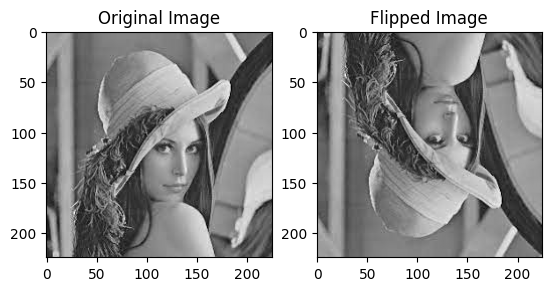

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

height,width = image_gray.shape
image_mirrored = np.zeros((height,width))

for i in range(height):
    for j in range(width):
        image_mirrored[i][j] = image_gray[height-i-1][j]

plt.subplot(1,2,1)
plt.imshow(image_gray,cmap="gray")
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(image_mirrored,cmap='gray')
plt.title("Flipped Image")


Text(0.5, 1.0, 'Flipped Image')

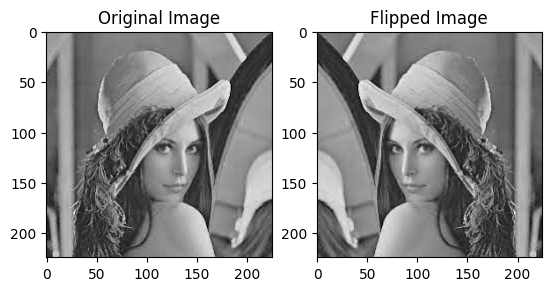

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

# Vertical Flip
height,width = image_gray.shape

image_mirrord = image_gray.copy()
for arr in image_mirrord:
    i = 0
    j = len(arr) - 1

    while i < j:
        temp = arr[i]
        arr[i ] = arr[j]
        arr[j] = temp
        
        i+=1
        j-=1

plt.subplot(1,2,1)
plt.imshow(image_gray,cmap="gray")
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(image_mirrord,cmap='gray')
plt.title("Flipped Image")

Text(0.5, 1.0, 'Thresholded Image')

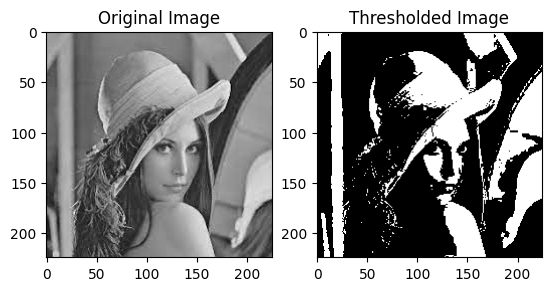

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

height,width = image_gray.shape
threasholded_image = np.zeros((height,width))
for i in range(height):
    for j in range(width):
        pixel = image_gray[i][j]

        if (pixel<150):
            pixel = 0
        else:
            pixel = 255
        
        threasholded_image[i][j] = pixel

plt.subplot(1,2,1)
plt.imshow(image_gray,cmap='gray')
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(threasholded_image,cmap='gray')
plt.title('Thresholded Image')

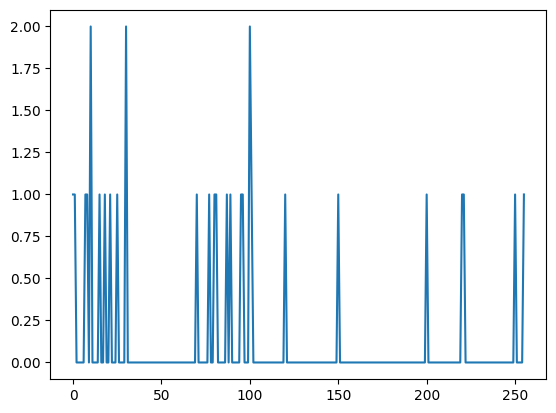

In [21]:
import numpy as np

import matplotlib.pyplot as plt

array = np.array([
    [255,0,1,100,25,101],
    [10,200,70,80,120,150],
    [95,30,30,81,96,77],
    [87,89,220,250,100,10],
    [18,7,221,21,8,15]
])
closest = np.max(array)

hist  = np.zeros(256)
height,width = np.shape(array)

for i in range(height):
    for j in range(width):
        hist[array[i,j]] +=1

plt.plot(hist)
plt.show()


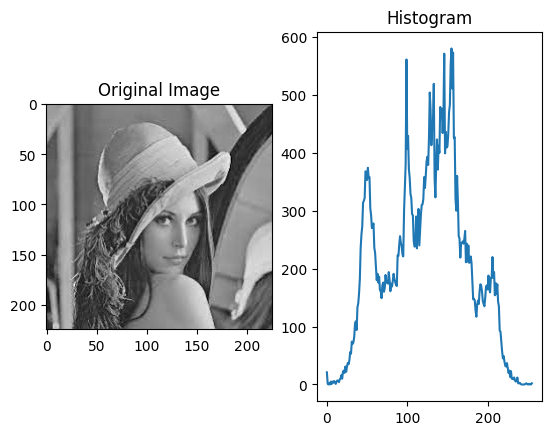

In [39]:
import numpy as np

import matplotlib.pyplot as plt

import cv2 


image  = cv2.imread('./a.jpg')
image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
largest_value_of_pixel = np.max(image)
nearest_2_power = np.log2(largest_value_of_pixel)
actual_2_power = 2 ** np.ceil(nearest_2_power)

height,width = image.shape

hist = np.zeros(int(actual_2_power))
for i in range(height):
    for j in range(width):
        hist[image[i,j]] +=1


plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_gray,cmap='gray')

plt.subplot(1,2,2)
plt.title("Histogram")

plt.plot(hist)

plt.show()


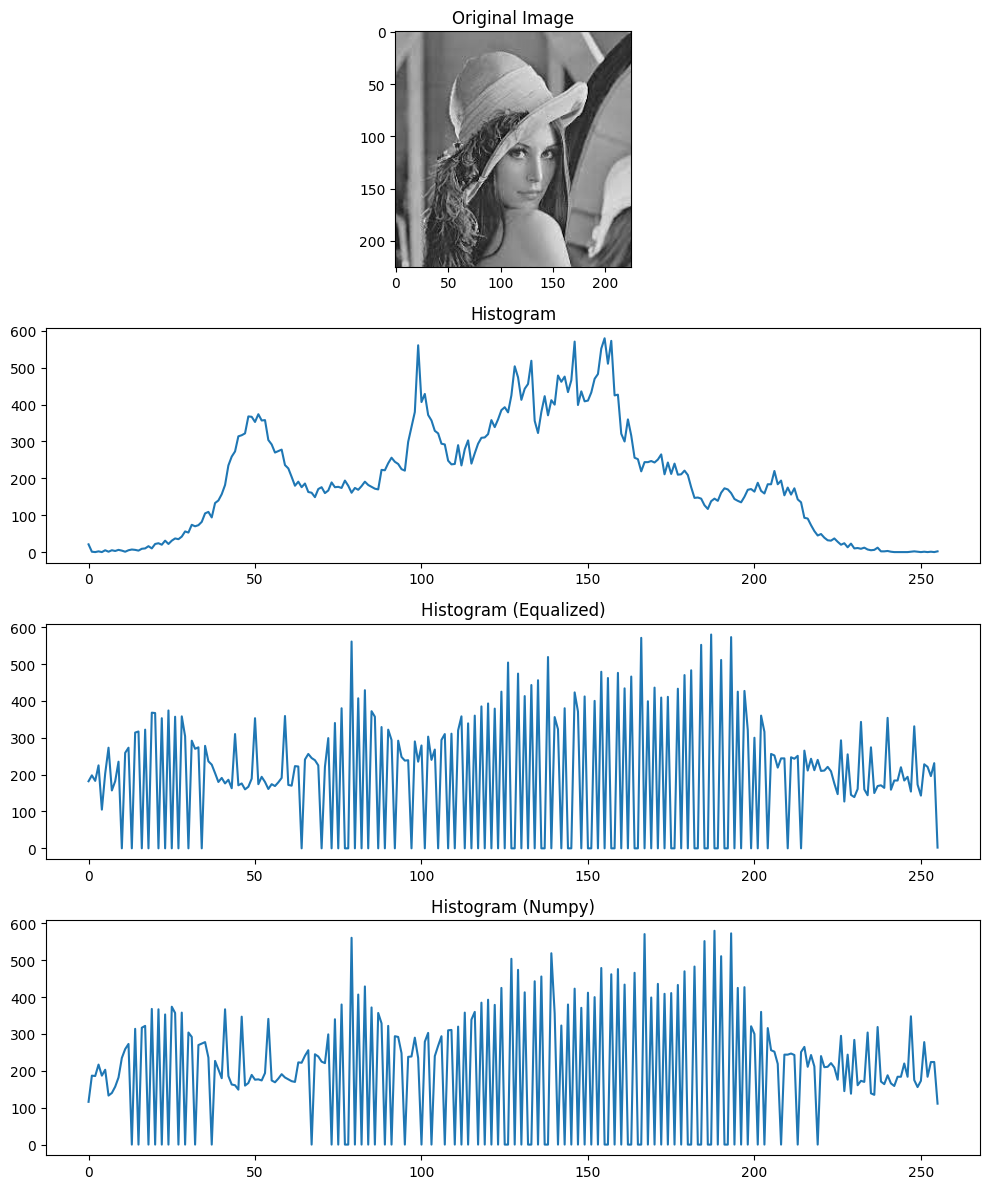

In [73]:
import numpy as np

import matplotlib.pyplot as plt

import cv2 


image  = cv2.imread('./a.jpg')
image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
largest_value_of_pixel = np.max(image)
nearest_2_power = np.log2(largest_value_of_pixel)
actual_2_power = 2 ** np.ceil(nearest_2_power)

height,width = image.shape

hist = np.zeros(int(actual_2_power))
for i in range(height):
    for j in range(width):
        hist[image[i,j]] +=1

total_pixels = height*width
pdf_arr = hist / total_pixels


cdf_arr = np.zeros(int(actual_2_power))
cdf_arr[0] = pdf_arr[0]
for i in range(1,int(actual_2_power)):
    cdf_arr[i] = cdf_arr[i-1]+pdf_arr[i]

normalized_cdf = []
for i in cdf_arr:
    normalized_cdf.append(int(i * (actual_2_power - 1)))

equalized = np.zeros((height,width), dtype=np.uint8)
for i in range(height):
    for j in range(width):
        equalized[i,j] = normalized_cdf[image[i,j]]

hist_equalized = np.zeros(256)
for i in range(height):
    for j in range(width):
        hist_equalized[equalized[i, j]] += 1

equalized_cv2 = cv2.equalizeHist(image)
hist_eq, bins_eq = np.histogram(equalized_cv2.flatten(), 256, [0, 256])

plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(4, 1, 2)
plt.title("Histogram")
plt.plot(hist)

plt.subplot(4, 1, 3)
plt.title("Histogram (Equalized)")
plt.plot(hist_equalized)


plt.subplot(4, 1, 4)
plt.title("Histogram (Numpy)")
plt.plot(hist_eq)

plt.tight_layout()
plt.show()